In [8]:
!pip install torchinfo


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/1e/1a/dcb50e44b75419e96b276c9fb023b0f147b3c411be1cd517492aa2a184d4/pandas-2.3.1-cp39-cp39-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.9 MB/s eta 0:00:00
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Obtaining dependency information for tzdata>=2022.7 from https://files.pythonhosted.org/packages/5c/23/c7abc0ca0a1526a0774eca151daeb8de62ec457e77262b66b359c3c7679e/tzdata-2025.2-py2.py3-none-any.whl.metadata
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8

In [9]:
import torch
from torch import nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary
from torch.optim import Adam
from torchvision import models

import numpy as np
import pandas as pd
import os
from PIL import Image
import numpy as np

from skimage import color
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

In [ ]:
# shutil.rmtree("/kaggle/working/")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

In [ ]:
device

In [ ]:
transformer = transforms.Compose([
    transforms.Resize((256, 256)),
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    # transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, base_dirs: dict, transformer=None):
        self.base_dirs = base_dirs
        self.transformer = transformer

        self.images = []
        for dir_ in self.base_dirs:
            for dir_list in self.base_dirs[dir_]:
                full_path = os.path.join(dir_, dir_list)
                for img in os.listdir(full_path):
                    if not img.endswith(".txt"):
                        full_img_path = os.path.join(dir_, dir_list, img)
                        self.images.append(full_img_path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert("RGB")
        except Exception as e:
            dummy_l = torch.zeros((1, 256, 256), dtype=torch.float32)
            dummy_ab = torch.zeros((2, 256, 256), dtype=torch.float32)
            return dummy_l, dummy_ab

        if self.transformer:
            img = self.transformer(img)

        img = img.permute(1, 2, 0)
        img = img.cpu().numpy()

        lab_img = color.rgb2lab(img)

        l_channel = lab_img[:, :, 0] / 100.0
        ab_channels = lab_img[:, :, 1:] / 128.0

        l_channel = torch.tensor(l_channel, dtype=torch.float32).unsqueeze(0)
        ab_channels = torch.tensor(ab_channels, dtype=torch.float32).permute(2, 0, 1)

        return l_channel, ab_channels

In [ ]:
main_dirs = {"/kaggle/input/places365/train": ["army_base", "canal-urban", "house", "park", "village", "industrial_area"]}
train_dataset = CustomDataset(main_dirs, transformer)

In [ ]:
len(train_dataset)

In [ ]:
train_data, val_data = random_split(train_dataset, [0.95, 0.05])

In [ ]:
len(train_data)

In [ ]:
len(val_data)

In [ ]:
x, y = train_data[90]
print(x.shape, type(x))

In [ ]:
len(train_data)

In [ ]:
batch_size = 64
train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)
val_dl = DataLoader(val_data, batch_size=batch_size, shuffle=True, num_workers=4)

In [ ]:
def get_lab(l_channel, ab_channels, device):
    l_channel = l_channel.cpu().numpy()
    a_channel = ab_channels[:, 0, :, :].unsqueeze(1).cpu().numpy()
    b_channel = ab_channels[:, 1, :, :].unsqueeze(1).cpu().numpy()

    l_channel = np.clip(l_channel * 100, 0, 100).astype(np.float32)
    a_channel = np.clip(a_channel * 128, -128, 127).astype(np.float32)
    b_channel = np.clip(b_channel * 128, -128, 127).astype(np.float32)

    # lab_image = np.stack([l_channel, a_channel, b_channel], axis=-1).astype(np.float32)
    lab_image = np.concatenate([l_channel, a_channel, b_channel], axis=1)

    lab_image = torch.tensor(lab_image, dtype=torch.float32).to(device)
    return lab_image

In [ ]:
l, ab = next(iter(train_dl))

images = get_lab(l, ab, device)
img = images[2]
img = img.permute(1, 2, 0).cpu().numpy()
img = color.lab2rgb(img)

plt.imshow(img)
plt.show()

In [ ]:
def output(limit, data):
    for i, (l_channel, ab_channels) in enumerate(data):
        gray_img = l_channel.permute(1, 2, 0).cpu().numpy()
        # print(gray_img.shape)
        l_channel = l_channel.cpu().numpy()

        a_channel = ab_channels[0].unsqueeze(0).cpu().numpy()
        b_channel = ab_channels[1].unsqueeze(0).cpu().numpy()

        a_channel = np.clip(a_channel * 128, -128, 127).astype(np.int8)
        b_channel = np.clip(b_channel * 128, -128, 127).astype(np.int8)
        l_channel = np.clip(l_channel * 100, 0, 100).astype(np.int8)

        lab_image = np.stack([l_channel, a_channel, b_channel], axis=-1).astype(np.float32)

        rgb_img = color.lab2rgb(lab_image)

        rgb_img = np.clip(rgb_img, 0, 1)

        rgb_img = rgb_img.squeeze(0)

        plt.subplot(1, 2, 1)
        plt.imshow(rgb_img)
        plt.title("Colorized")

        plt.subplot(1, 2, 2)
        plt.imshow(gray_img, cmap="gray")
        plt.title("Grayscaled")

        plt.show()

        if i+1 >= limit:
            break





In [ ]:
output(5, train_data)

In [ ]:
output(5, val_data)

In [ ]:
class DiscrConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, bnorm=False):
        super().__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)

        if bnorm == True:
            self.bnorm = nn.BatchNorm2d(out_channels)
        else:
            self.bnorm = nn.Identity()

    def forward(self, x):
        return F.leaky_relu(self.bnorm(self.conv(x)), 0.2)



In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            DiscrConvBlock(3, 64, 4, 2, 1, False),
            DiscrConvBlock(64, 128, 4, 2, 1, True),
            DiscrConvBlock(128, 256, 4, 2, 1, True),
            DiscrConvBlock(256, 512, 4, 1, 1, True),
        )

        self.out = nn.Conv2d(512, 1, 4, 2, 1)

    def forward(self, x):
        out = self.net(x)
        return self.out(out)

In [ ]:
# calculate the patch size according to this formula R = R + (k - 1) * J,
# where:

# J - step on previouse level
# k - kernel size
# R - size of patch on each itteration
# s - kernel, size

lst = [(4, 2), (4, 2), (4, 2), (4, 1), (4, 2)]
R = 1
J = 1

for k, s in lst:
  R = R + (k - 1) * J
  J = J * s

print(f"{R}x{R}")

In [ ]:
discriminator = Discriminator()
tensor = torch.randn(1, 3, 256, 256)
out = discriminator(tensor)
out.shape

In [ ]:
summary(discriminator, input_data=torch.randn(1, 3, 256, 256))

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, bnorm=False, upsample=True):
        super().__init__()

        if upsample == True:
            self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        else:
            self.upsample = nn.Identity()

        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)

        if bnorm == False:
            self.bnorm = nn.Identity()
        elif bnorm == True:
            self.bnorm = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.upsample(x)
        out = F.leaky_relu(self.bnorm(self.conv(x)), 0.2)
        return out

In [ ]:
block = ConvBlock(512, 128, 3, 1, 1, False, True)
tensor = torch.randn(1, 512, 2, 2)

out = block(tensor)
print(out.shape)

In [ ]:
class DeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, norm=False, upsample=False):
        super().__init__()

        if upsample == True:
            self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        else:
            self.upsample = nn.Identity()

        self.conv = nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)

        if norm == True:
            self.bnorm = nn.InstanceNorm2d(out_channels)
        else:
            self.bnorm = nn.Identity()

        # if dropout == False:
        #     self.dropout = nn.Identity()
        # elif dropout == True:
        #     self.dropout = nn.Dropout2d(p=0.3)

    def forward(self, x):
        x = self.upsample(x)
        out = F.leaky_relu(self.bnorm(self.conv(x)), 0.2)
        return out

In [ ]:
class SEBLock(nn.Module):
    def __init__(self, C, r=16):
        super().__init__()

        self.aap = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        self.linear1 = nn.Linear(C, C//r)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(C//r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.aap(x)
        out = self.flatten(out)

        out = self.relu(self.linear1(out))
        out = self.sigmoid(self.linear2(out))

        out = out[:, :, None, None]

        res = x * out

        return res

In [ ]:
tensor = torch.randn(1, 64, 64, 64)
block = SEBLock(64)

out = block(tensor)
out.shape

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # 1, 128, 128
        self.conv1 = ConvBlock(1, 64, 4, 2, 1, True, False)
        self.se1 = SEBLock(64)
        # 64, 64, 64
        self.conv2 = ConvBlock(64, 64, 4, 2, 1, True, False)
        self.se2 = SEBLock(64)
        # 64, 32, 32
        self.conv3 = ConvBlock(64, 128, 4, 2, 1, True, False)
        self.se3 = SEBLock(128)
        # 128, 16, 16
        self.conv4 = ConvBlock(128, 256, 4, 2, 1, True, False)
        self.se4 = SEBLock(256)
        # 128, 8, 8
        self.conv5 = ConvBlock(256, 512, 4, 2, 1, True, False)
        self.se5 = SEBLock(512)
        # 512, 4, 4
        self.bottle_neck = nn.Conv2d(512, 512, 4, 1, 3, dilation=2)
        self.se6 = SEBLock(512)
        # 256, 4, 4

        self.up_conv1 = DeConvBlock(1024, 256, 4, 2, 1, True)
        self.se7 = SEBLock(256)
         # 256, 4, 4

        self.up_conv2 = DeConvBlock(512, 128, 4, 2, 1, True)
        self.se8 = SEBLock(128)

        self.up_conv3 = DeConvBlock(256, 64, 4, 2, 1, True)
        self.se9 = SEBLock(64)

        self.up_conv4 = DeConvBlock(128, 64, 4, 2, 1, True)
        self.se10 = SEBLock(64)

        self.up_conv5 = DeConvBlock(128, 2, 4, 2, 1, True)

        self.up_conv6 = nn.Conv2d(3, 2, 3, 1, 1)



    def forward(self, x):
        out1 = self.se1(self.conv1(x))

        out2 = self.se2(self.conv2(out1))

        out3 = self.se3(self.conv3(out2))

        out4 = self.se4(self.conv4(out3))

        out5 = self.se5(self.conv5(out4))

        b = self.se6(self.bottle_neck(out5))

        d_out_1 = torch.cat((b, out5), dim=1)
        d_out_2 = self.se7(self.up_conv1(d_out_1))

        d_out_2 = torch.cat((d_out_2, out4), dim=1)
        d_out_3 = self.se8(self.up_conv2(d_out_2))

        d_out_3 = torch.cat((d_out_3, out3), dim=1)
        d_out_4 = self.se9(self.up_conv3(d_out_3))

        d_out_4 = torch.cat((d_out_4, out2), dim=1)
        d_out_5 = self.se10(self.up_conv4(d_out_4))

        d_out_5 = torch.cat((d_out_5, out1), dim=1)
        d_out_6 = self.up_conv5(d_out_5)

        out = torch.cat((d_out_6, x), dim=1)
        out = self.up_conv6(out)

        out = torch.tanh(out)


        return out

    def predict(self, l):
        self.eval()

        with torch.no_grad():
            ab = self.forward(l)

        l_channel = l.squeeze(0).cpu().numpy()
        a_channel = ab[:, 0, :, :].cpu().numpy()
        b_channel = ab[:, 1, :, :].cpu().numpy()

        l_channel = np.clip(l_channel*100, 0, 100).astype(np.uint8)
        a_channel = np.clip(a_channel*128, -128, 127).astype(np.int8)
        b_channel = np.clip(b_channel*128, -128, 127).astype(np.int8)

        # print(l_channel.shape, a_channel.shape, b_channel.shape)


        lab_image = np.stack([l_channel, a_channel, b_channel], axis=-1).astype(np.float64)


        rgb_image = color.lab2rgb(lab_image)

        rgb_image = (rgb_image * 255).astype(np.uint8)
        rgb_image = rgb_image.squeeze(0)


        return rgb_image

In [ ]:
generator = Generator()
tensor = torch.randn(1, 1, 256, 256)
out = generator(tensor)
out.shape

In [ ]:
generator = Generator()
l = torch.randn(1, 1, 256, 256)
res = generator.predict(l)
res.shape

In [ ]:
l, _ = train_data[0]
gray_img = l.permute(1, 2, 0)
pred = generator.predict(l.unsqueeze(0))

plt.subplot(1, 2, 1)
plt.imshow(pred)
plt.title("Predicted")

plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap="gray")
plt.title("Original")

plt.show()

In [ ]:
summary(generator, input_data=torch.randn(1, 1, 256, 256))

In [ ]:
g_loss = nn.MSELoss()
d_loss = nn.MSELoss()

In [ ]:
G_optimizer = Adam(generator.parameters(), lr=1e-3)
D_optimizer = Adam(discriminator.parameters(), lr=1e-5)

In [ ]:
generator.to(device)
discriminator.to(device)

In [ ]:
# vgg calculates difference only between rgb images, so we need to transform LAB-images to RGB-format

def lab_to_rgb(lab_image_tensor, device):
    lab_image_tensor = lab_image_tensor.permute(0, 2, 3, 1)
    lab_image = lab_image_tensor.detach().cpu().numpy()
    # color cannot handle tensors with Batch > 1, so we create an array of lab-images transformed to
    rgb_image = np.array([color.lab2rgb(img) for img in lab_image])
    rgb_tensor = torch.from_numpy(rgb_image).float().to(device)
    rgb_tensor = rgb_tensor.permute(0, 3, 1, 2)
    return rgb_tensor

In [ ]:
lab_tensor = torch.rand(64, 3, 256, 256)
rgb_tensor = lab_to_rgb(lab_tensor, device)
rgb_tensor.shape

In [ ]:
def train(train_dl, G_optimizer, D_optimizer, G, D, g_loss, d_loss, device, epochs, g_step, to_display, lamda_l1, perceptual_loss=None, val_dl=None, perceptual_weight=0.1):
    history = {
        "G_train_loss": [],
        "D_train_loss": [],
        "G_val_loss": [],
        "D_val_loss": []
    }

    for epoch in range(epochs):
        G.train()
        D.train()

        gen_train_loss = 0
        disc_train_loss = 0

        for l, ab in tqdm(train_dl):

            D_optimizer.zero_grad()

            l = l.to(device)
            ab = ab.to(device)

            # B, _, _, _ = l.shape

            fake_ab = G(l)
            # fake_lab = get_lab(l, fake_ab, device)
            # real_lab = get_lab(l, ab, device)

            fake_lab = torch.cat((l, fake_ab), dim=1)
            lab = torch.cat((l, ab), dim=1)

            D_fake = D(fake_lab)
            D_real = D(lab)

            real_labels = torch.full_like(D_real, 0.9, device=device)
            fake_labels = torch.zeros_like(D_fake, device=device)

            D_loss_real = d_loss(real_labels, D_real)
            D_loss_fake = d_loss(fake_labels, D_fake)
            D_loss = (D_loss_real + D_loss_fake) / 2

            disc_train_loss += D_loss.item()

            D_loss.backward()
            D_optimizer.step()

            for _ in range(g_step):
                G_optimizer.zero_grad()

                fake_ab = G(l)
                # fake_lab = get_lab(l, fake_ab, device)
                fake_lab = torch.cat((l, fake_ab), dim=1)
                G_adv_loss = g_loss(D(fake_lab), real_labels)
                G_l1_loss = F.l1_loss(fake_ab, ab)

                if perceptual_loss is not None:
                    # fake_rgb = color.lab2rgb(fake_lab)
                    # real_rgb = color.lab2rgb(lab)
                    fake_rgb = lab_to_rgb(fake_lab, device)
                    real_rgb = lab_to_rgb(lab, device)

                    p_loss = F.mse_loss(perceptual_loss(fake_rgb), perceptual_loss(real_rgb))
                    G_loss = G_adv_loss + G_l1_loss * lamda_l1 + p_loss * perceptual_weight

                else:
                    G_loss = G_adv_loss + G_l1_loss * lamda_l1


                gen_train_loss += G_loss.item()

                G_loss.backward()
                G_optimizer.step()

        if val_dl is not None:
            G.eval()
            D.eval()

            gen_val_loss = 0.0
            disc_val_loss = 0.0

            with torch.no_grad():
              for l, ab in tqdm(val_dl):
                l = l.to(device)
                ab = ab.to(device)

                fake_ab = G(l)

                fake_lab = torch.cat((l, fake_ab), dim=1)
                real_lab = torch.cat((l, ab), dim=1)

                D_real = D(real_lab)
                D_fake = D(fake_lab)

                real_labels = torch.full_like(D_real, 0.9, device=device)
                fake_labels = torch.zeros_like(D_fake, device=device)

                D_loss_reals = d_loss(D_real, real_labels)
                D_loss_fakes = d_loss(D_fake, fake_labels)

                D_loss = (D_loss_reals + D_loss_fakes) / 2

                disc_val_loss += D_loss.item()

                G_adv_loss = g_loss(D(fake_lab), real_labels)
                G_l1_los = F.l1_loss(fake_ab, ab)

                G_loss = G_adv_loss + G_l1_loss * lamda_l1

                gen_val_loss += G_loss.item()


        plt.figure(figsize=(to_display * 2, 2))
        for i in range(to_display):
            single_l = l[i:i+1]
            # single_l = single_l.unsqueeze(0)
            pred = G.predict(single_l)
            plt.subplot(1, to_display, i+1)
            plt.imshow(pred)
            plt.axis('off')
        plt.show()

        generator_train_loss = gen_train_loss / len(train_dl)
        discriminator_train_loss = disc_train_loss / len(train_dl)

        if val_dl is not None:
            generator_val_loss = gen_val_loss / len(val_dl)
            discriminator_val_loss = disc_val_loss / len(val_dl)

        history["G_train_loss"].append(generator_train_loss)
        history["D_train_loss"].append(discriminator_train_loss)

        if val_dl is not None:
            history["G_val_loss"].append(generator_val_loss)
            history["D_val_loss"].append(discriminator_val_loss)

        if epoch % 10 == 0:
            torch.save(G.state_dict(), f"GAN_{epoch}_epochs.pt")

        if val_dl is not None:
            print(f"Epoch: {epoch+1}, Generator_train_loss: {generator_train_loss:.4f}, Discriminator_train_loss: {discriminator_train_loss:.4f}, Generator_val_loss: {generator_val_loss:.4f}, Discriminator_val_loss: {discriminator_val_loss:.4f}")
        else:
            print(f"Epoch: {epoch+1}, Generator_train_loss: {generator_train_loss:.4f}, Discriminator_train_loss: {discriminator_train_loss:.4f}")
    return history









In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# generator_weights = "/kaggle/input/new-weights/new_pretrained_weights/GAN_colorizer_v04_G.pt"
# generator.load_state_dict(torch.load(generator_weights,  map_location=device))

# discriminator_weights = "/kaggle/input/new-weights/new_pretrained_weights/GAN_colorizer_v03_D.pt"
# discriminator.load_state_dict(torch.load(discriminator_weights,  map_location=device))

In [ ]:
history = train(train_dl, G_optimizer, D_optimizer, generator, discriminator, g_loss, d_loss, device, 35, 2, 6, lamda_l1=40, perceptual_loss=None, val_dl=val_dl, perceptual_weight=0.1)

In [ ]:
def output_metrics(history, sample):
    plt.plot(history[f"G_{sample}_loss"], label="Generator")
    plt.plot(history[f"D_{sample}_loss"], label="Discriminator")
    plt.title(f"{sample} set")
    plt.xlabel("Epochs")
    plt.xlabel("Losses")
    plt.legend()
    plt.show()


In [ ]:
output_metrics(history, "train")

In [ ]:
output_metrics(history, "val")

In [71]:
def output(data, device, limit):
  plt.figure(figsize=(14, 9))
  for i, (l, ab) in enumerate(data):
    l = l.unsqueeze(0).to(device)
    pred = generator.predict(l)

    plt.subplot(5, 5, i+1)
    plt.imshow(pred)
    plt.axis("off")


    if i >= limit:
      break
  plt.show()

In [74]:
torch.save(generator.state_dict(), "GAN_colorizer_G.pt")
torch.save(discriminator.state_dict(), "GAN_colorizer_D.pt")

In [67]:
t_transformer = transformer = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [77]:
dirs = {'/kaggle/input/historical-photos-7': ["data_05"]}
test_dataset = CustomDataset(dirs, transformer=t_transformer)

In [69]:
num = len(test_dataset) - 1

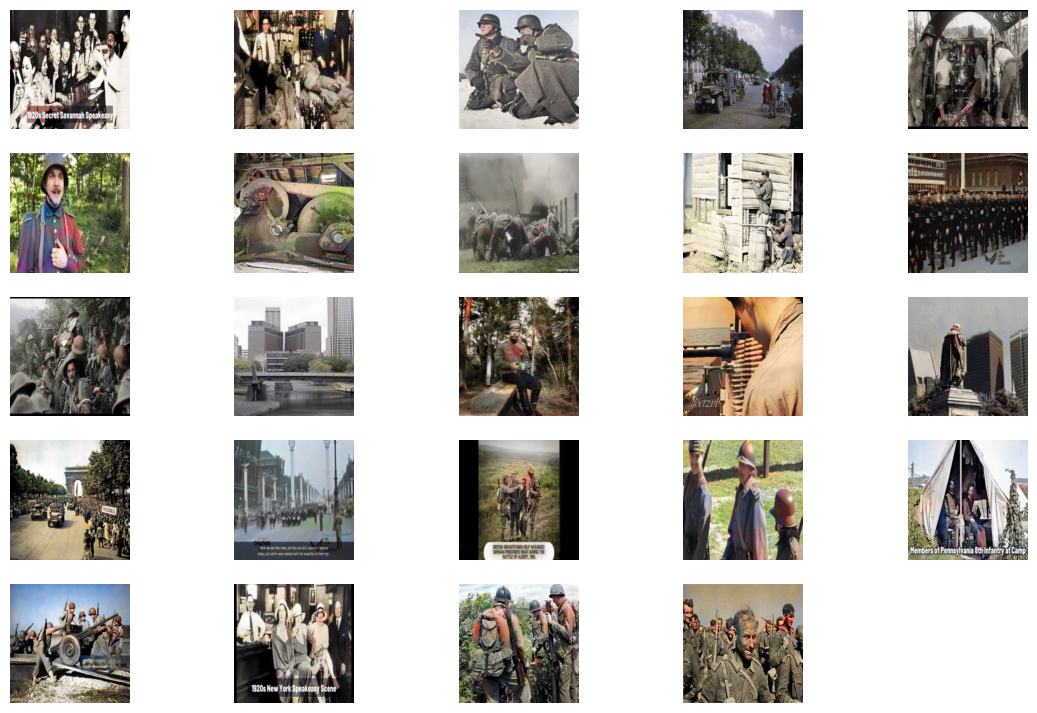

In [79]:
output(test_dataset, device, 23)

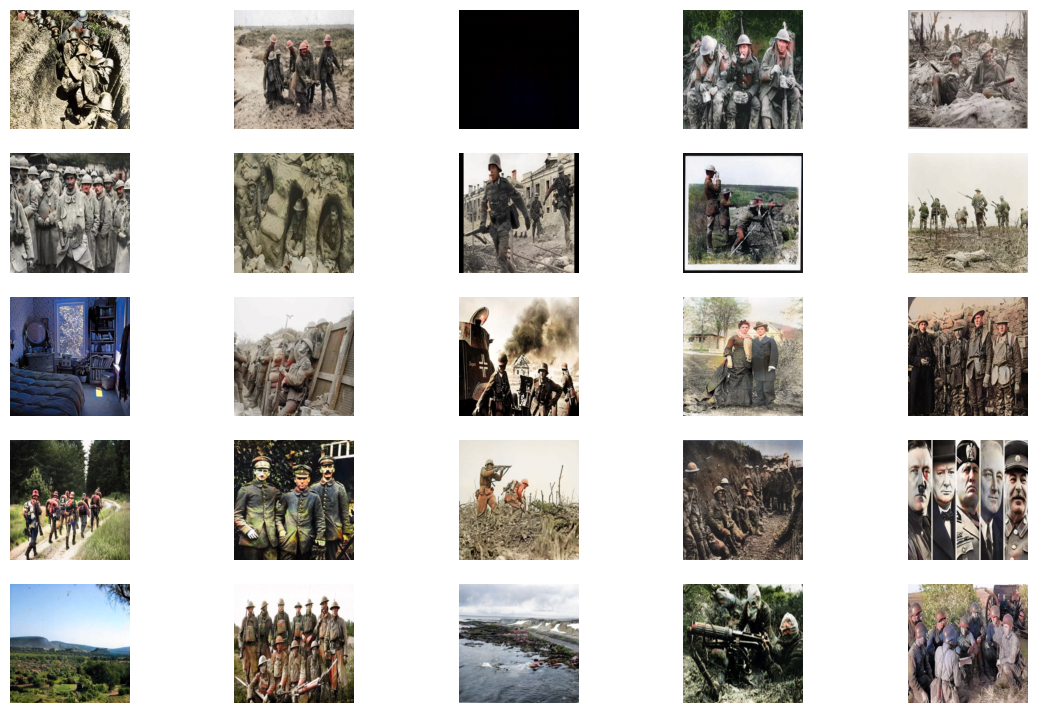

In [76]:
dirs = {'/kaggle/input/final-test': ["grayscaled_images"]}
test_dataset = CustomDataset(dirs, transformer=t_transformer)
num = len(test_dataset) - 1
output(test_dataset, device, 24)